In [127]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Mon Feb 22 20:09:58 2021

@author: ronguy
"""

import numpy as np
import matplotlib

import matplotlib.pyplot as plt

import time
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.cluster import KMeans
import umap
from sklearn.cluster import DBSCAN
from sklearn import metrics

from tqdm import tqdm_notebook
from lmfit import minimize, Parameters
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as pl
import shap

import sys
sys.path.append("/Users/ronguy/Dropbox/Work/CyTOF/")
%load_ext autoreload
%autoreload 2

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

import sys
sys.path.append("/Users/ronguy/Dropbox/Work/CyTOF/")
sys.path.append("/Users/ronguy/Dropbox/Work/CyTOF/Code/")
sys.path.append("/Users/ronguy/Dropbox/Work/CyTOF/BRCA_SHAP/")
%load_ext autoreload
%autoreload 2
from CyTOFHelper import *
from TestHet import *
from PermCell_Smooth import *
#from SHAPset import *
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

import xgboost as xgb
import umap
import matplotlib.pyplot as plt
import anndata as ad
import scanpy as sc
import pandas as pd
from POgSET import *
import icecream as ic

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Load and initialize

In [128]:
import glob

In [129]:
dir="/Users/ronguy/Dropbox/CyTOF_Breast/CyTOF_CR7/CyTOF7_scMCF7/csv_scale_value/"

In [130]:
FList=glob.glob(dir+"*")

In [131]:
FList.sort()
FList

['/Users/ronguy/Dropbox/CyTOF_Breast/CyTOF_CR7/CyTOF7_scMCF7/csv_scale_value/exp01_exp_relevant.csv',
 '/Users/ronguy/Dropbox/CyTOF_Breast/CyTOF_CR7/CyTOF7_scMCF7/csv_scale_value/exp02_exp_relevant.csv',
 '/Users/ronguy/Dropbox/CyTOF_Breast/CyTOF_CR7/CyTOF7_scMCF7/csv_scale_value/exp03_exp_relevant.csv',
 '/Users/ronguy/Dropbox/CyTOF_Breast/CyTOF_CR7/CyTOF7_scMCF7/csv_scale_value/exp04_exp_relevant.csv',
 '/Users/ronguy/Dropbox/CyTOF_Breast/CyTOF_CR7/CyTOF7_scMCF7/csv_scale_value/exp05_exp_relevant.csv',
 '/Users/ronguy/Dropbox/CyTOF_Breast/CyTOF_CR7/CyTOF7_scMCF7/csv_scale_value/exp06_exp_relevant.csv']

In [132]:
DBs=[f"exp{i:02}" for i in range(1,7)]

In [133]:
DBs=['MCF7_Yael','MCF7_Uri','MCF7_C5','MCF7_Yael_P','MCF7_C3','MCF7_C4']

In [134]:
for F,DB in zip(FList,DBs):
    print(F)
    globals()[DB]=pd.read_csv(F,)

/Users/ronguy/Dropbox/CyTOF_Breast/CyTOF_CR7/CyTOF7_scMCF7/csv_scale_value/exp01_exp_relevant.csv
/Users/ronguy/Dropbox/CyTOF_Breast/CyTOF_CR7/CyTOF7_scMCF7/csv_scale_value/exp02_exp_relevant.csv
/Users/ronguy/Dropbox/CyTOF_Breast/CyTOF_CR7/CyTOF7_scMCF7/csv_scale_value/exp03_exp_relevant.csv
/Users/ronguy/Dropbox/CyTOF_Breast/CyTOF_CR7/CyTOF7_scMCF7/csv_scale_value/exp04_exp_relevant.csv
/Users/ronguy/Dropbox/CyTOF_Breast/CyTOF_CR7/CyTOF7_scMCF7/csv_scale_value/exp05_exp_relevant.csv
/Users/ronguy/Dropbox/CyTOF_Breast/CyTOF_CR7/CyTOF7_scMCF7/csv_scale_value/exp06_exp_relevant.csv


In [135]:
Rep=dict(zip(list(MCF7_Yael.columns),[f.split("_")[-1] for f in list(MCF7_Yael.columns)]))

In [136]:
Rep

{'116Cd_H3K9me3': 'H3K9me3',
 '140Ce_KRT5': 'KRT5',
 '161Dy_H4K20me3': 'H4K20me3',
 '163Dy_ER': 'ER',
 '164Dy_CD49f': 'CD49f',
 '166Er_CD24': 'CD24',
 '167Er_GATA3': 'GATA3',
 '168Er_H3K27me3': 'H3K27me3',
 '170Er_H3K18ac': 'H3K18ac',
 '151Eu_H3K9me2': 'H3K9me2',
 '153Eu_H2A119Ub': 'H2A119Ub',
 '155Gd_H3.3': 'H3.3',
 '156Gd_H3K64ac': 'H3K64ac',
 '157Gd_BMI1': 'BMI1',
 '158Gd_ZEB1': 'ZEB1',
 '160Gd_H3K27Ac': 'H3K27Ac',
 '165Ho_H3K36me3': 'H3K36me3',
 '115In_H3': 'H3',
 '175Lu_H3S28p': 'H3S28p',
 '142Nd_H3K27me2': 'H3K27me2',
 '143Nd_p53': 'p53',
 '144Nd_EZH2': 'EZH2',
 '145Nd_H3K4me3': 'H3K4me3',
 '148Nd_NSD1': 'NSD1',
 '150Nd_H3K4me1': 'H3K4me1',
 '141Pr_EpCAM': 'EpCAM',
 '147Sm_pH2A.X': 'pH2A.X',
 '149Sm_H3K36me2': 'H3K36me2',
 '152Sm_H4K16ac': 'H4K16ac',
 '154Sm_Vimentin': 'Vimentin',
 '159Tb_H4': 'H4',
 '169Tm_H3K9ac': 'H3K9ac',
 '171Yb_CD44': 'CD44',
 '172Yb_Ki67': 'Ki67',
 '174Yb_KRT8-18': 'KRT8-18'}

In [137]:
for DB in DBs:
    globals()[DB].rename(columns=Rep,inplace=True)

In [138]:
#dir="/Users/ronguy/Dropbox/WIS-CIMA colab - Analysis/#3 CyTOF  - KPC sample, after CD45 depletion/"

params = {'axes.titlesize': 30,
          'legend.fontsize': 20,
          'figure.figsize': (6, 5),
          'axes.labelsize': 20,
          'axes.titlesize': 20,
          'xtick.labelsize': 20,
          'ytick.labelsize': 20,
          'figure.titlesize': 30}
plt.rcParams.update(params)

sns.set_style("white")


In [139]:
Rep=dict(pd.read_excel("/Users/ronguy/Dropbox/Work/CyTOF/Mapping.xlsx").iloc[:,:].values)

In [140]:
Rep['H3K27Ac']='H3K27ac'

In [141]:
for F,DB in zip(FList,DBs):
#    globals()[DB]=pd.read_csv(F)
    globals()[DB].rename(columns=Rep,inplace=True)
#    globals()[DB].drop(columns=['DNA1','DNA2','Event #'],inplace=True)

In [142]:
N=list(MCF7_Yael.columns)
N.sort()


In [143]:
N

['BMI1',
 'CD24',
 'CD44',
 'CD49f',
 'ER',
 'EZH2',
 'EpCAM',
 'GATA3',
 'H2AK119ub',
 'H3',
 'H3.3',
 'H3K18ac',
 'H3K27ac',
 'H3K27me2',
 'H3K27me3',
 'H3K36me2',
 'H3K36me3',
 'H3K4me1',
 'H3K4me3',
 'H3K64ac',
 'H3K9ac',
 'H3K9me2',
 'H3K9me3',
 'H3S28p',
 'H4',
 'H4K16ac',
 'H4K20me3',
 'KI67',
 'KRT5',
 'KRT8-18',
 'NSD1',
 'Vimentin',
 'ZEB1',
 'p53',
 'pH2A.X']

In [144]:
DBs

['MCF7_Yael', 'MCF7_Uri', 'MCF7_C5', 'MCF7_Yael_P', 'MCF7_C3', 'MCF7_C4']

In [145]:
Run="MCF7_C4"

In [146]:
DBs=[Run]

In [147]:
NamesAll,EpiCols,NormMRK,CellIden,CellCyle=GetMarkers(N)

In [148]:
EpiCols.remove('BMI1')
CellIden.append('BMI1')

In [149]:
EpiCols.remove('EZH2')
CellIden.append('EZH2')

In [150]:
%matplotlib inline
hKWD={'element':'step','fill':False,'stat':'density'}

In [151]:
len(NamesAll)

35

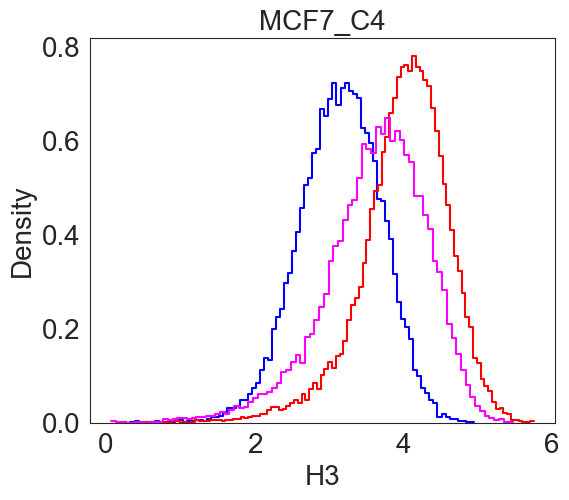

In [152]:
for DB in DBs:
    plt.figure()
    D=np.arcsinh(globals()[DB]/5).copy()
    sns.histplot(data=D,x='H3',**hKWD,color='blue')
    sns.histplot(data=D,x='H3.3',**hKWD,color='red')
    sns.histplot(data=D,x='H4',**hKWD,color='magenta')
#    sns.histplot(data=D,x='H2A',**hKWD,color='g')
    plt.title(DB)
#plt.xscale('log')
#plt.yscale('log')

## Gate on H3.3/H2A too low, but also remove outliers 99.99% from all 

In [153]:
GateColumns=['H3.3','H4','H3']



def Gate(data,name):
    ddf=data.copy()
    print(name)
    print("Initial ",len(ddf))
    ddf=ddf[(ddf[GateColumns]>5).all(axis=1)]
    print("Core Gate ",len(ddf))
#    ddf=ddf[(ddf<np.quantile(ddf,0.9999,axis=0)).all(axis=1)]
    print("Outlier Gate ",len(ddf))
    data=ddf.copy()
    del ddf
    return data




In [154]:
for DB in DBs:
    globals()[DB]=Gate(globals()[DB],DB)



MCF7_C4
Initial  20562
Core Gate  20505
Outlier Gate  20505


# Normalize using new method on all intercellular markers

In [155]:
def R(p,x,data,Q,M,M1,M2,M3):
    a=p['a']
    b=p['b']
    d=x.divide(a*M1+(1-a-b)*M2+b*M3,axis=0)
    return d.std()['H3.3']**2+d.std()['H4']**2+d.std()['H3']**2

def NormalizeNew(data):
    
    params = Parameters()
    params.add('a', value=0.1,min=0,max=1)
    params.add('b', value=0.1,min=0,max=1)
    ddf=data.copy()
    ddf2=data.copy()
    Q=ddf.mean()
    M=(ddf/Q)[['H3.3','H4','H3']].mean(axis=1)
    M1=(ddf/Q)['H3.3']
    M2=(ddf/Q)['H4']
    M3=(ddf/Q)['H3']

    out=minimize(R, params ,args=(ddf, ddf,Q,M,M1,M2,M3),method='cg')
    AA=out.params['a'].value
    BB=out.params['b'].value
    M=M1*AA+M2*(1-AA-BB)+M3*BB
    ddf=ddf.divide(M,axis=0).copy()
    data=ddf
    ddf2[NormMRK]=data[NormMRK]
    data=ddf2.copy()
    print(data.shape,ddf2.shape)

    del ddf 
    del ddf2
    return data
    
def R2(p,x,data,Q,M,M1,M2):
    a=p['a']
    d=x.divide(a*M1+(1-a)*M2,axis=0)
    return (d.std()['H3.3'])**2+(d.std()['H4'])**2

def NormalizeNew2(data):
    
    params = Parameters()
    params.add('a', value=0.5,min=0.1,max=1)
    ddf=data.copy()
    ddf2=data.copy()
    Q=ddf[NormMRK].mean()
    M=(ddf/Q)[['H3.3','H4']].mean(axis=1)
    M1=(ddf/Q)['H3.3']
    M2=(ddf/Q)['H4']
 
    out=minimize(R2, params ,args=(ddf[NormMRK], ddf[NormMRK],Q,M,M1,M2),method='cg')
    AA=out.params['a'].value
    print(AA)
    M=M1*AA+M2*(1-AA)
    ddf[NormMRK]=ddf[NormMRK].divide(M,axis=0).copy()
    data=ddf.copy()
    print(data.shape,ddf2.shape)
    ddf2[NormMRK]=data[NormMRK]
    data=ddf2.copy()
    del ddf 
    del ddf2
    return data

In [156]:
for DB in DBs:
    globals()[DB]=NormalizeNew(globals()[DB])



(20505, 35) (20505, 35)


In [157]:
scFac=5
for DB in DBs:
    globals()[DB]=np.arcsinh(globals()[DB]/scFac)


In [158]:
NMS=NamesAll.copy()
NMS=list(set(NMS).difference(set(['H3','H3.3','H4'])))

In [159]:
MRK_All=NamesAll.copy()
MRK_All.remove('H3')
MRK_All.remove('H3.3')
MRK_All.remove('H4')
#MRK_All.remove('H2A')

EPC=EpiCols.copy()
Core=['H3','H3.3','H4']#,'H2A']
for C in Core:
    EPC.remove(C)

In [160]:
NC=2000
aaaa=pd.DataFrame(columns=globals()[DBs[0]].columns)
for DB in DBs:
    aaaa=pd.concat([aaaa,globals()[DB].sample(NC,replace=False)]).copy()
                  

                
m=np.mean(aaaa,axis=0)
s=np.std(aaaa,axis=0)

for DB in DBs:
    globals()[DB]=(globals()[DB]-m)/s
    globals()[DB]['Line']=DB


params = {'axes.titlesize': 30,
          'legend.fontsize': 20,
          'figure.figsize': (6, 5),
          'axes.labelsize': 20,
          'axes.titlesize': 20,
          'xtick.labelsize': 20,
          'ytick.labelsize': 20,
          'figure.titlesize': 30}
plt.rcParams.update(params)

sns.set_style("white")

/var/folders/sm/c5y90hdx37s36m0309zwd4zm0000gn/T/ipykernel_86577/3139609166.py:4: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  aaaa=pd.concat([aaaa,globals()[DB].sample(NC,replace=False)]).copy()


In [161]:
DF=pd.concat([globals()[DB] for DB in DBs],axis=0)

In [162]:
DF.reset_index(inplace=True,drop=True)

In [163]:
adata=ad.AnnData(DF[NMS],obs=DF[['Line']])

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [164]:

adata.write_h5ad("../../data/MCF7.h5ad")